# Code interprétation NN apprenant Q-function dans Schelling

In [15]:
# A chnager pour faire evoluer les parametres :
 #Classe Mind : cahnger la strucutre du reseau 
 #Schelling ex : R (=1 ou plus)

## 1. Imports et fonctions pour plot

In [1]:
import os, sys, random, time, shutil
import numpy as np
import torch
import torch.nn.functional as F
from multiprocessing import Lock

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from matplotlib.patches import Patch
from IPython.display import HTML
from scipy.ndimage import label as scipy_label

from environment import Environment
from schelling_example import *

Metrics defined.


In [2]:
_CMAP  = mcolors.ListedColormap(['#4a90d9', '#f5f5f5', '#e05252', '#f5a623'])
_BOUNDS = [-1.5, -0.5, 0.5, 1.5, 2.5]
_NORM  = mcolors.BoundaryNorm(_BOUNDS, _CMAP.N)
_LEGEND = [
    Patch(facecolor='#4a90d9', edgecolor='#aaa', label='Empty'),
    Patch(facecolor='#f5f5f5', label='Type A (−1)'),
    Patch(facecolor='#e05252', label='Type B (+1)'),
    Patch(facecolor='#f5a623', label='Prey (2)'),
]

def show_grid(grid, title='', ax=None):
    """Render one map snapshot."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid, cmap=_CMAP, norm=_NORM, interpolation='nearest')
    ax.set_title(title, fontsize=12, pad=6)
    ax.axis('off')
    ax.legend(handles=_LEGEND, loc='lower right', fontsize=7, framealpha=0.9)
    if standalone:
        plt.tight_layout()
        plt.show()

def show_snapshots(grids_dict, suptitle=''):
    """Row of snapshots at given timesteps."""
    steps = sorted(grids_dict)
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))
    if len(steps) == 1:
        axes = [axes]
    for ax, t in zip(axes, steps):
        show_grid(grids_dict[t], title=f't = {t}', ax=ax)
    if suptitle:
        plt.suptitle(suptitle, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Paramètres de la simulation

In [3]:
GRID_SIZE    = (50, 50)
P_HUNTER     = 0.05      # densité par type  (~10% des cases sont occupées)
P_PREY       = 0.0       # pas de proie, les auteurs ont prévu des systèmes plus riches
AGENT_RANGE  = 1         # réglage de la fenetre d'attention de l'agent 2*r+1 x 2*r+1 (ex : Schelling = r=1)
PREY_REWARD  = 0         # gamma reward multiplier (IR) essayer avec 25 (segregation max, avec alpha = 1)
MAX_AGE      = 100       # age max des agents
ALPHA        = 1.0       # weight of opposite-type neighbor penalty
BETA         = 1.0       # weight of alive bonus
GAMMA        = 1.0       # weight of predation reward
ITERATIONS   = 2000     # max steps
EPS_CONV     = 1e-6      # convergence threshold (paper default)
SNAP_STEPS   = [0, 50, 100, 150, 200, 249]  # steps to snapshot
EPISODES     = 1         # number of iterated experiments (I guess) 

EXP_NAME = 'small4'

## 3. Initialisation de la simulatoin et entrainement

Environment created.
  A agents : 118
  B agents : 143
  Empty    : 2239
  Segregation initiale (rayon=1): 0.482


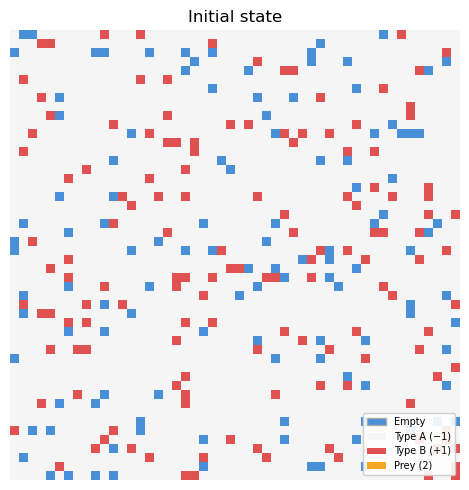

In [4]:
society = Schelling(
    GRID_SIZE,
    p_hunter      = P_HUNTER,
    p_prey        = P_PREY,
    prey_reward   = PREY_REWARD,
    agent_max_age = MAX_AGE,
    agent_range   = AGENT_RANGE,
    max_iteration = ITERATIONS,
    lock          = Lock(),
    name          = EXP_NAME,
    alpha         = ALPHA,
    beta          = BETA,
    gamma         = GAMMA,
)

initial_grid = society.get_map().copy()
counts = count_agents(initial_grid)

print('Environment created.')
print(f'  A agents : {counts["A"]}')
print(f'  B agents : {counts["B"]}')
print(f'  Empty    : {counts["empty"]}')
print(f'  Segregation initiale (rayon=1): {global_segregation(initial_grid):.3f}')

show_grid(initial_grid, title='Initial state')

In [5]:
q_A_time, q_B_time = play(society, episodes=EPISODES, iterations=ITERATIONS, eps=EPS_CONV,
                          log_q=True, log_every=80, n_avg=200)

I: 5	Time Elapsed: 0.06

/home/paul-guimbard/Bureau/ICFP/S2/ML/projet /segregation/mind.py:142: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/task_177081057165514/croot/libtorch_1770810630944/work/torch/csrc/utils/tensor_new.cpp:254.)
  batch_state = torch.cat([torch.FloatTensor(s) for s in batch_state])


SIMULATION IS FINISHED..07


On peut voir l'amélioration dans l'approximation de la fonction Q par les deux réseaux de neurones en présentant l'évolution de la MSE loss. La convergence semble rapide et mener à un plateau.

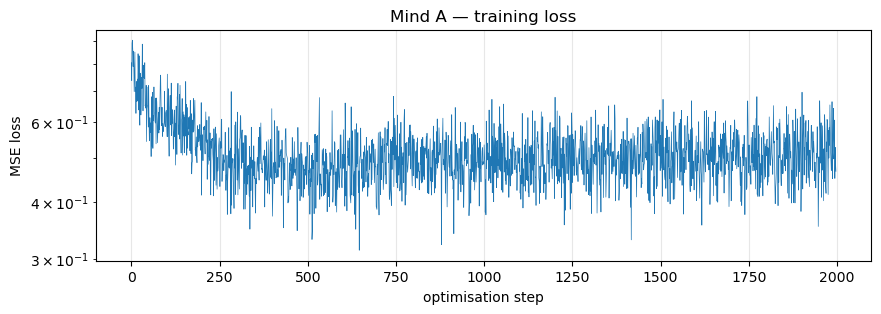

In [6]:
losses = society.A_mind.losses

plt.figure(figsize=(10,3))
plt.plot(losses, lw=0.5)
plt.yscale('log')
plt.title('Mind A — training loss')
plt.xlabel('optimisation step'); plt.ylabel('MSE loss')
plt.grid(alpha=0.3)
plt.show()


On peut regarder la dynamique produite par notre réseau après un certain temps d'entrainement avec une approche $\epsilon$-greedy, choisissant souvent de suivre la politique maximisant les valeurs de la fonction Q approximées par les réseaux.

  step   50/100  |  elapsed 0.05s
  Stopped: reached max iterations (100)


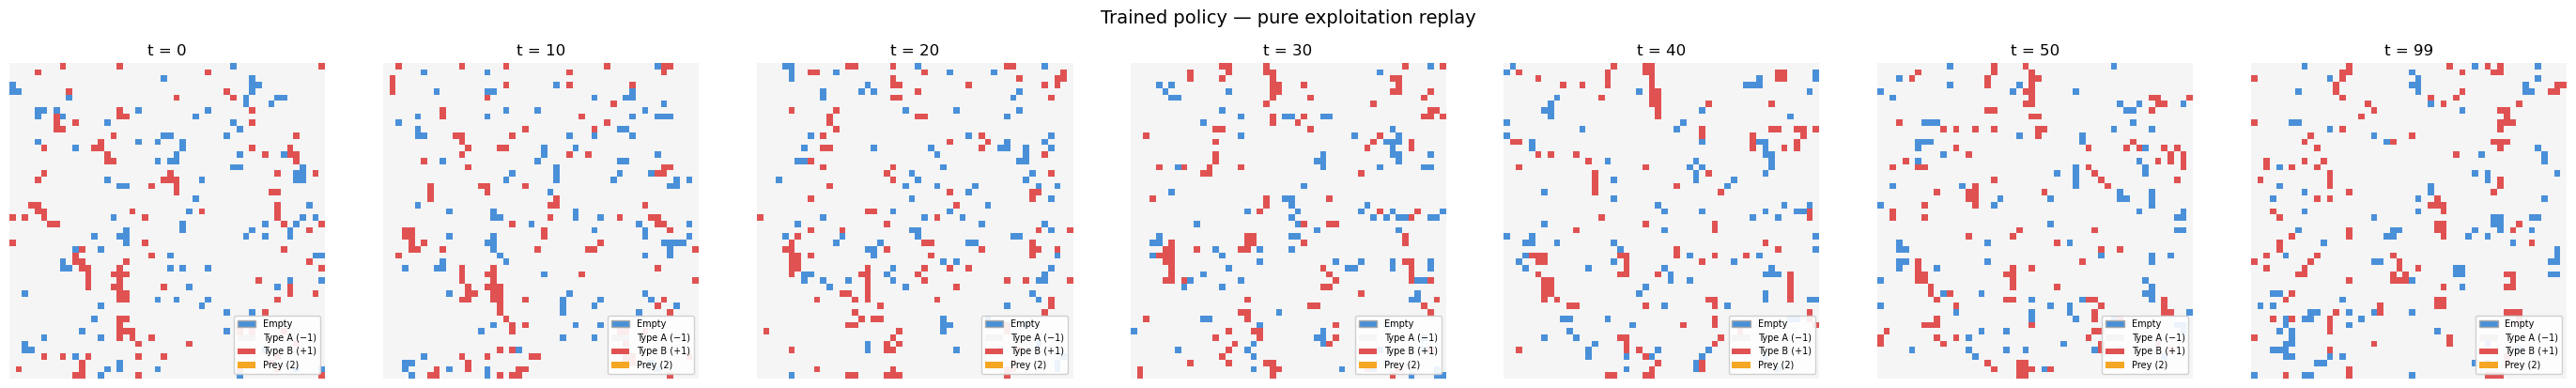

In [7]:
snaps = replay_snapshots(
    society,
    iterations = 100,
    snap_steps = [0,10,20,30,40,50,100],
    verbose    = True,
)

show_snapshots(snaps, suptitle='Trained policy — pure exploitation replay')

On voit quelques phénomènes de ségregation par notre réseau, retrouvant les résultats de l'article avec un diagramme de phase qui ressemblerait à celui du modèle de Schelling.

## 4. Interprétation des réseaux 

### 4.1 Comportement moyen dans le temps (étude de la loi marginale d'un certain nombre de pas de simulation)

In [8]:
net_A = society.A_mind
net_B = society.B_mind

In [9]:
print(f'Structure du réseau pour A : '+str(type(net_A.network).__name__))
print(f'Nombre de paramètres du réseau pour A  : {sum(p.numel() for p in net_A.network.parameters()):,}')

print(f'Structure du réseau pour B : '+str(type(net_B.network).__name__))
print(f'Nombre de paramètres du réseau pour B  : {sum(p.numel() for p in net_B.network.parameters()):,}')

Structure du réseau pour A : DQN
Nombre de paramètres du réseau pour A  : 70
Structure du réseau pour B : DQN
Nombre de paramètres du réseau pour B  : 70


On dispose de deux réseaux profonds cherhant à approximer une fonction de coût Q(état agent, contexte), avec 250 paramètres.

On va désormais produire de nombreux contextes pour estimer empiriquement la valeur moyenne de la fonction Q pour chacun des actions selon le type de l'agent (A ou B) : $\left <Q(agent, contexte,action)\right >_{contexte}$

In [10]:
ACTION_NAMES = ['Up', 'Left', 'Down', 'Right', 'Stay']


In [11]:
for agent_type, mind, type_sign in [('A', society.A_mind, -1), ('B', society.B_mind, 1)]:
    q = get_qvals_avg(mind, agent_type, f_same=0.041, f_opp=0.05,
                      type_sign=type_sign, n_avg=200)
    print(f'\nQ-values for type {agent_type}, f_s=0.041, f_o=0.05 (avg over 200 patches):')
    for a_name, qv in zip(ACTION_NAMES, q):
        print(f'  {a_name:6s}: {qv:+.4f}')
    print(f'  => greedy action: {ACTION_NAMES[int(np.argmax(q))]}')



Q-values for type A, f_s=0.041, f_o=0.05 (avg over 200 patches):
  Up    : +9.6974
  Left  : -5.5129
  Down  : -13.3149
  Right : -0.2461
  Stay  : -10.8636
  => greedy action: Up

Q-values for type B, f_s=0.041, f_o=0.05 (avg over 200 patches):
  Up    : +8.1718
  Left  : -5.3083
  Down  : -11.9739
  Right : +0.7442
  Stay  : -11.3432
  => greedy action: Up


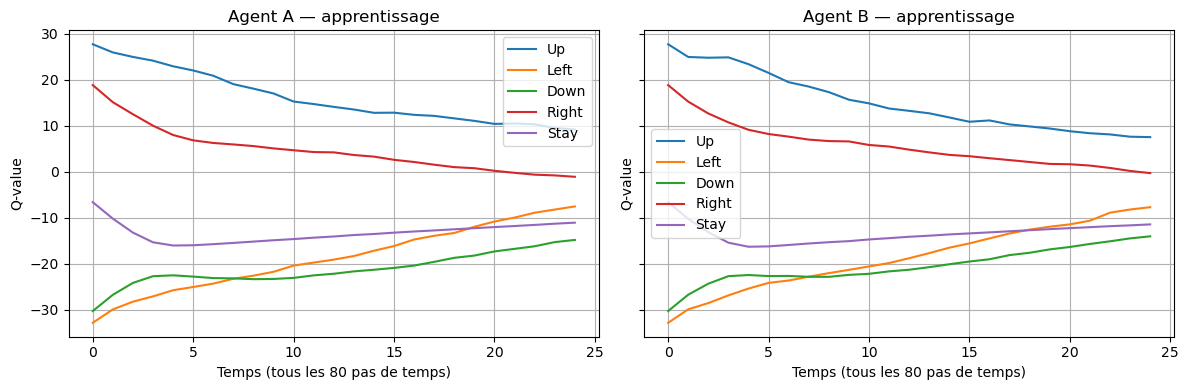

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, action in enumerate(ACTION_NAMES):
    axes[0].plot(q_A_time[:, i], label=action)
    axes[1].plot(q_B_time[:, i], label=action)

axes[0].set_title("Agent A — apprentissage")
axes[1].set_title("Agent B — apprentissage")

for ax in axes:
    ax.set_xlabel("Temps (tous les 80 pas de temps)")
    ax.set_ylabel("Q-value")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

On remarque une convergence des deux réseaux vers une même valeur pour les déplacements et une valeurplus basse pour l'immobilité. On retrouve une expression de l'ergodicité du processus, qui en moyenne explore toutes les directions, et favorisant le déplacement à l'immobilité. Il est intéressant de noter que ce comportement proche de celui d'un modèle de marcheurs ivres, donne une organisation spatiale avec des détails plus grands que les fenêtres d'attention des agents, quand les marcheurs ivres ne donneraient que des configurations désorganisées.

Il serait intéressant de considérer le transport de la loi de probabilité de présence des agents ou de la fonction de corrélation spatiale.

### 4.2 Analyse des symétries des poids des réseaux

On passe ici à une version très peu expressive de nos réseaux afin de ressembler au plus au modèle de Schelling (4 variables internes, 1 seule layer). Le résultat n'est pas bon, mais permet de se faire une idée des outils développés ici pour anaalyser un réseau.

- Etude statistique des poids (on s'attend à des distributions d'équilibres de processus stochastiques liés à leur indépendance et leur grand nombre, une trop faible variance serait mauvais signe).
- Etude de ce que 'regarde' chaque représentation latente du contexte, via les poids du réseau. L'attention est là où les poids on une valeur importante.
- Etude des critères utilisés pour les actions : les poids de la dernière couche donne l'information sur le lien entre contexte et décision pour le réseau.

In [16]:
def plot_weight_hist(model, title="Model"):
    all_weights = []

    for p in model.parameters():
        all_weights.append(p.detach().cpu().numpy().ravel())

    all_weights = np.concatenate(all_weights)

    plt.figure(figsize=(5, 3))
    plt.hist(all_weights, bins=50)
    plt.title(f"{title} — weight distribution")
    plt.xlabel("value")
    plt.ylabel("count")
    plt.grid(True)
    plt.show()
    
def plot_conv_filters(model, title="Model"):
    conv = model.l1.weight.detach().cpu().numpy()  # shape (16, 1, 3, 3)

    fig, axes = plt.subplots(2, 2, figsize=(12, 3))

    for i, ax in enumerate(axes.flat):
        filt = conv[i, 0]  # remove channel dim
        im = ax.imshow(filt)
        ax.set_title(f"F{i}")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(f"{title} — Conv filters")
    plt.tight_layout()
    plt.show()

def plot_linear_weights(model, title="Model"):
    w = model.out.weight.detach().cpu().numpy()  # shape (5, 17)

    plt.figure(figsize=(6, 3))
    im = plt.imshow(w, aspect='auto')
    plt.colorbar(im)

    plt.title(f"{title} — Linear layer (actions x features)")
    plt.xlabel("features")
    plt.ylabel("actions")
    plt.yticks(range(5), ["Up", "Left", "Down", "Right", "Stay"])

    plt.show()

def analyze_dqn(model, title="Model"):
    plot_weight_hist(model, title)
    plot_conv_filters(model, title)
    plot_linear_weights(model, title)

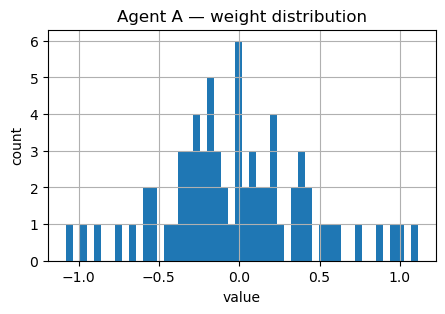

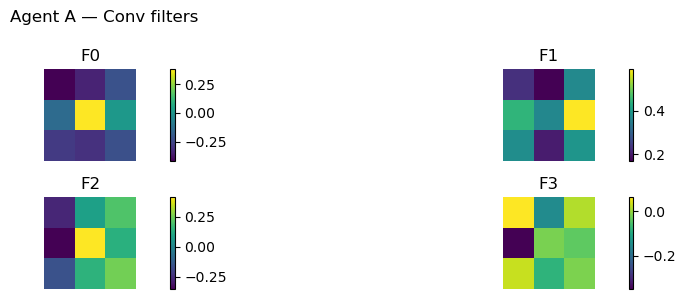

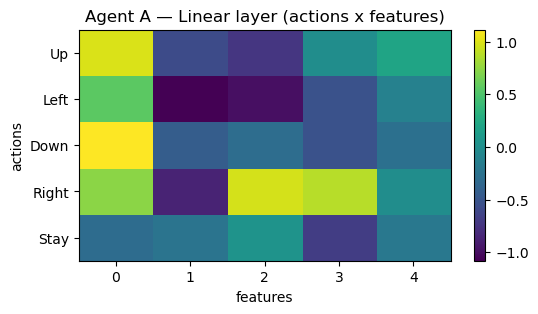

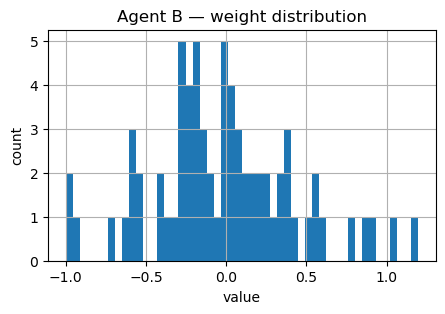

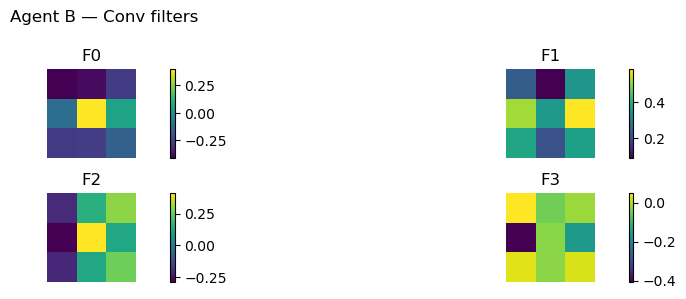

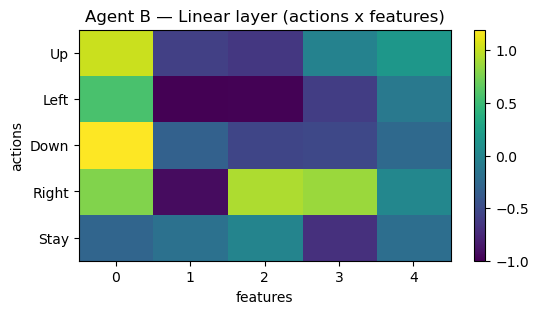

In [17]:
analyze_dqn(society.A_mind.network, "Agent A")
analyze_dqn(society.B_mind.network, "Agent B")

## 5. Idées pour aller plus loin : différence entre modèle sans traitement du contexte et avec, pour comprendre ce qui les différencie et comment faire la jonction entre les deux. On cherche l'apparition d'une théorie à basse température en partant d'une haute tempréature (sans traitement du contexte)


────────────────────────────────────────────────────────────
NULL MODEL: Random walk (uniform Q)
  Segregation trajectory: {0: '0.526', 50: '0.684', 100: '0.650', 200: '0.619', 299: '0.650'}

────────────────────────────────────────────────────────────
NULL MODEL: Always move Up (degenerate)
  Segregation trajectory: {0: '0.526', 50: '0.460', 100: '0.000', 200: '0.500', 299: '0.513'}

────────────────────────────────────────────────────────────
NULL MODEL: Always Stay (inertia)
  Segregation trajectory: {0: '0.526', 20: '0.526'}


NameError: name 'snaps_fresh' is not defined

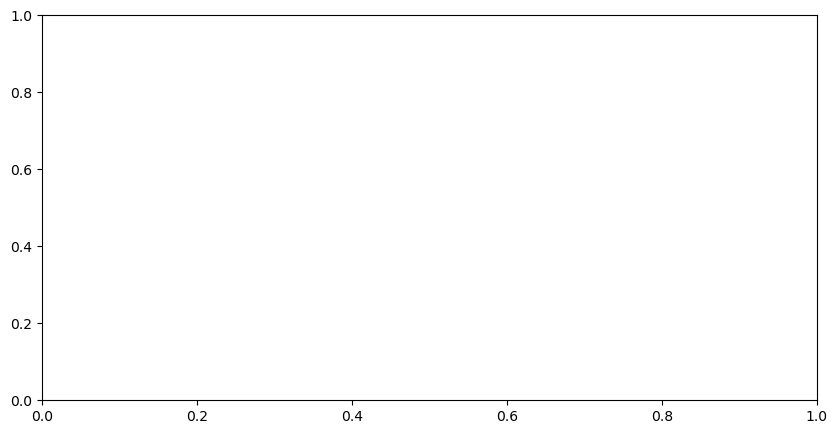

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# NULL MODEL (d) — Mean Q-values from trained network
#
# For each action, compute the average Q-value across a wide sample of random
# neighbourhoods. Use those 5 scalars as a fixed Q-vector. This captures the
# trained network's global action preference (e.g. the Up bias) while removing
# all neighbourhood-conditional information.
#
# If this null model produces the same segregation as the trained DQN, then the
# neighbourhood-sensitivity of the network adds nothing — the Up bias alone
# explains the result.
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2 — Null model with constant Q-values
#
# Replace the trained DQN with a dummy network whose output is FIXED regardless
# of input. We test three sub-cases:
#
#   (a) RANDOM WALK     — all Q-values equal → uniform random action each step
#   (b) ALWAYS MOVE UP  — mimics the degenerate policy the broken training gave
#   (c) ALWAYS STAY     — extreme inertia baseline
#
# If any of these produce segregation, it means segregation in the real model
# is NOT caused by the learned neighbourhood-sensitive policy — it would be a
# purely demographic / spatial artefact.
# ═══════════════════════════════════════════════════════════════════════════════

import torch.nn as nn
import types

NEW_SEED = 23

class ConstantQNetwork(nn.Module):
    """
    Dummy network that returns a fixed Q-value vector regardless of input.
    Inherits nn.Module so it is drop-in compatible with Mind.network.
    """
    def __init__(self, q_values: list):
        super().__init__()
        # Store as a parameter so .state_dict() / .eval() work normally
        self.register_buffer('fixed_q',
                             torch.tensor(q_values, dtype=torch.float32))

    def forward(self, x, age):
        # Return the same Q-vector for every item in the batch
        batch = x.shape[0]
        return self.fixed_q.unsqueeze(0).expand(batch, -1)


def make_null_society(q_values_A, q_values_B, seed, exp_name):
    """
    Build a fresh Schelling environment and replace both DQNs with
    ConstantQNetwork instances producing the given fixed Q-vectors.
    """
    if os.path.isdir(exp_name):
        shutil.rmtree(exp_name)
    

    np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)

    soc = Schelling(
        GRID_SIZE,
        p_hunter=P_HUNTER, p_prey=P_PREY, prey_reward=PREY_REWARD,
        agent_max_age=MAX_AGE, agent_range=AGENT_RANGE,
        max_iteration=ITERATIONS, lock=Lock(),
        name=exp_name, alpha=ALPHA, beta=BETA, gamma=GAMMA,
    )

    # Swap in constant networks
    soc.A_mind.network = ConstantQNetwork(q_values_A)
    soc.B_mind.network = ConstantQNetwork(q_values_B)

    # Force ε=0 so decide() always takes the greedy (fixed) action
    soc.A_mind.steps_done = int(1e9)
    soc.B_mind.steps_done = int(1e9)

    return soc


# ── Define the three null models ──────────────────────────────────────────────
#   Q-vector order: [Up, Left, Down, Right, Stay]

null_models = {
    'Random walk\n(uniform Q)':
        ([0., 0., 0., 0., 0.],   [0., 0., 0., 0., 0.]),   # argmax=0 (Up) — but ε-greedy
    'Always move Up\n(degenerate)':
        ([1., 0., 0., 0., 0.],   [1., 0., 0., 0., 0.]),   # always Up
    'Always Stay\n(inertia)':
        ([0., 0., 0., 0., 1.],   [0., 0., 0., 0., 1.]),   # always Stay
}

# Note: "Random walk" with ε=0 and uniform Q also always picks Up (argmax tie
# broken by index 0). To get a true random walk we override decide() instead:

def random_decide(self, state, age=None):
    """Pure uniform random action — true null model."""
    return random.randrange(self.num_actions)


# ── Run all null models and collect segregation trajectories ──────────────────
SNAP_STEPS_NULL = [0, 50, 100, 200, 300]
null_results    = {}

for label, (qA, qB) in null_models.items():
    print(f'\n{"─"*60}')
    print(f'NULL MODEL: {label.replace(chr(10)," ")}')

    soc = make_null_society(qA, qB, seed=NEW_SEED, exp_name=f'null_{label[:6]}')

    # For the random walk: patch decide() to be truly uniform random
    # For the random walk: patch Mind.decide() to be truly uniform random
# Signature must match: self, state, age, type
    if 'Random' in label:
        soc.A_mind.decide = types.MethodType(
            lambda self, state, age, type: random.randrange(self.num_actions),
            soc.A_mind)
        soc.B_mind.decide = types.MethodType(
            lambda self, state, age, type: random.randrange(self.num_actions),
            soc.B_mind)


    snaps = replay_snapshots(soc, iterations=300, snap_steps=SNAP_STEPS_NULL,
                              verbose=False)
    seg   = {t: global_segregation(snaps[t]) for t in sorted(snaps)}
    null_results[label] = {'snaps': snaps, 'seg': seg}
    print(f'  Segregation trajectory: { {t: f"{s:.3f}" for t,s in seg.items()} }')


# ── Side-by-side segregation trajectories: trained vs null models ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Trained model on fresh grid
seg_trained = [global_segregation(snaps_fresh[t]) for t in sorted(snaps_fresh)]
ax.plot(sorted(snaps_fresh), seg_trained,
        color='black', lw=3, marker='o', ms=7, label='Trained DQN', zorder=5)

colors = ['#e05252', '#4a90d9', '#f5a623']
for (label, res), col in zip(null_results.items(), colors):
    steps = sorted(res['seg'])
    vals  = [res['seg'][t] for t in steps]
    ax.plot(steps, vals, color=col, lw=2, ls='--', marker='s', ms=5,
            label=label.replace('\n', ' '))

ax.axhline(global_segregation(initial_fresh), color='gray', ls=':',
           lw=1.5, label='Initial (random) S')

ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Global segregation index S', fontsize=11)
ax.set_title('Trained DQN vs. Null models — segregation dynamics', fontsize=13)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('null_model_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved null_model_comparison.pdf')


# ── Visual grid comparison at final step ──────────────────────────────────────
all_models = {'Trained DQN': snaps_fresh, **{k: v['snaps'] for k,v in null_results.items()}}
final_step = min(min(s.keys()) for s in all_models.values())   # last common step
# use the last captured step for each
last_snaps = {k: v[max(v.keys())] for k, v in all_models.items()}

n = len(last_snaps)
fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4.5))
cmap = plt.cm.RdBu_r

for ax, (label, grid) in zip(axes, last_snaps.items()):
    blurred = blur_grid(grid, radius=AGENT_RANGE, mode='gaussian')
    im = ax.imshow(blurred, cmap=cmap, vmin=-0.6, vmax=0.6,
                   interpolation='bilinear', origin='upper')
    seg_val = global_segregation(grid)
    ax.set_title(f'{label}\nS = {seg_val:.3f}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Final grid state: trained DQN vs. null models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('null_model_grids.pdf', bbox_inches='tight')
plt.show()
print('Saved null_model_grids.pdf')

def compute_mean_qvectors(mind, agent_type, type_sign,
                           n_fs=10, n_fo=5, n_patches=50, age=50.0):
    """
    Sample Q-values from the trained network across a grid of (f_s, f_o)
    combinations and return the per-action mean.

    Parameters
    ----------
    mind       : trained Mind object
    agent_type : 'A' or 'B'
    type_sign  : -1 or +1
    n_fs       : number of f_s values to sample
    n_fo       : number of f_o values to sample
    n_patches  : random patches per (f_s, f_o) point
    age        : agent age to feed to the network

    Returns
    -------
    mean_q : (N_ACTIONS,) numpy array — one scalar per action
    """
    rng        = np.random.default_rng(0)
    fs_values  = np.linspace(0, 1,   n_fs)
    fo_values  = np.linspace(0, 0.5, n_fo)   # cap at 0.5 — higher is rarely feasible
    accumulate = np.zeros(N_ACTIONS)
    count      = 0

    for fs in fs_values:
        for fo in fo_values:
            if fs + fo > 1.0 + 1e-6:
                continue
            for _ in range(n_patches):
                patch = make_patch_realistic(agent_type, fs, fo, rng=rng)
                x_t   = torch.FloatTensor(patch).unsqueeze(0).unsqueeze(0)
                age_t = torch.FloatTensor([[age]])
                with torch.no_grad():
                    q = mind.network(type_sign * x_t, age_t)
                accumulate += q.squeeze().numpy()
                count += 1

    mean_q = accumulate / count
    return mean_q


# ── Compute mean Q-vectors from both trained networks ────────────────────────
print('Computing mean Q-vectors from trained networks...')
mean_q_A = compute_mean_qvectors(society.A_mind, 'A', type_sign=-1,
                                  n_fs=10, n_fo=5, n_patches=50)
mean_q_B = compute_mean_qvectors(society.B_mind, 'B', type_sign=+1,
                                  n_fs=10, n_fo=5, n_patches=50)

print('\nMean Q-vector — Type A:')
for a, q in zip(ACTION_NAMES, mean_q_A):
    print(f'  {a:6s}: {q:+.4f}')

print('\nMean Q-vector — Type B:')
for a, q in zip(ACTION_NAMES, mean_q_B):
    print(f'  {a:6s}: {q:+.4f}')


# ── Add this null model to the existing null_models dict ─────────────────────
null_models['Mean Q (action bias\nno neighbourhood)'] = (
    list(mean_q_A),
    list(mean_q_B),
)

# ── Run it ────────────────────────────────────────────────────────────────────
label = 'Mean Q (action bias\nno neighbourhood)'
qA, qB = null_models[label]

print(f'\n{"─"*60}')
print('NULL MODEL: Mean Q — action bias without neighbourhood sensitivity')

soc_meanq = make_null_society(
    qA, qB,
    seed     = NEW_SEED,
    exp_name = 'null_meanq',
)

snaps_meanq = replay_snapshots(
    soc_meanq,
    iterations = 300,
    snap_steps = SNAP_STEPS_NULL,
    verbose    = False,
)
seg_meanq = {t: global_segregation(snaps_meanq[t]) for t in sorted(snaps_meanq)}
null_results[label] = {'snaps': snaps_meanq, 'seg': seg_meanq}

print(f'  Segregation trajectory:')
for t, s in seg_meanq.items():
    print(f'    t={t:4d}  S={s:.3f}')


# ── Updated comparison plot: 4 null models + trained DQN ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: segregation trajectories ───────────────────────────────────────────
ax = axes[0]
ax.plot(sorted(snaps_fresh), seg_trained,
        color='black', lw=3, marker='o', ms=7, label='Trained DQN', zorder=5)

colors = ['#e05252', '#4a90d9', '#f5a623', '#9467bd']
for (lbl, res), col in zip(null_results.items(), colors):
    steps = sorted(res['seg'])
    vals  = [res['seg'][t] for t in steps]
    ax.plot(steps, vals, color=col, lw=2, ls='--', marker='s', ms=5,
            label=lbl.replace('\n', ' '))

ax.axhline(global_segregation(initial_fresh), color='gray', ls=':',
           lw=1.5, label='Initial (random) S')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Global segregation index S', fontsize=11)
ax.set_title('Segregation dynamics: trained DQN vs. null models', fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Right: bar chart of final segregation values ──────────────────────────────
ax = axes[1]
all_labels  = ['Trained DQN'] + [k.replace('\n', ' ') for k in null_results]
final_segs  = [seg_trained[-1]] + [
    v['seg'][max(v['seg'].keys())] for v in null_results.values()
]
bar_colors  = ['black'] + colors

bars = ax.bar(range(len(all_labels)), final_segs,
              color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(global_segregation(initial_fresh), color='gray', ls=':',
           lw=1.5, label='Initial S')
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Final segregation index S', fontsize=11)
ax.set_title('Final segregation by model', fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Annotate bars with values
for bar, val in zip(bars, final_segs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=8, color='black')

plt.suptitle('Neighbourhood sensitivity vs. action bias: causal decomposition',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('null_model_comparison_full.pdf', bbox_inches='tight')
plt.show()
print('Saved null_model_comparison_full.pdf')


## 6. Distribution des ages à la dernière évaluation (fin de l'entrainement)

Crystal shape: (2000, 50, 50, 4)
  Channels: [agent_type, age, time_remaining, agent_id]
  Steps recorded: 2000

Tracked 118 type-A agents, 143 type-B agents


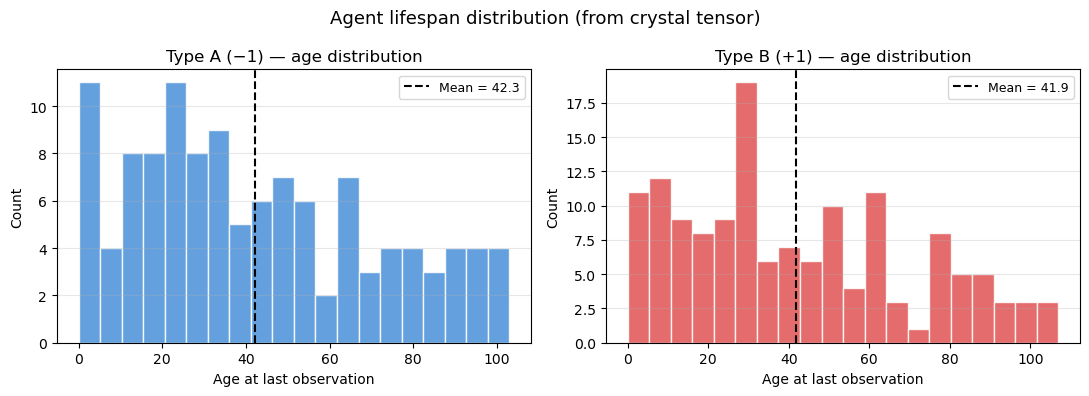

In [23]:
crystal_path = f'{EXP_NAME}/crystal.npy.gz'

import gzip
with gzip.GzipFile(crystal_path, 'r') as f:
    crystal = np.load(f)

T, H, W, C = crystal.shape
print(f'Crystal shape: {crystal.shape}')
print(f'  Channels: [agent_type, age, time_remaining, agent_id]')
print(f'  Steps recorded: {T}')

# ── Extract age-at-death via agent_id tracking ────────────────────────────────
#
# For each agent_id, find the last step it appears on the map.
# Its age at that step (crystal[t, i, j, 1]) is its age at death.

id_last_age  = {}   # agent_id -> age at last recorded step
id_type_seen = {}   # agent_id -> type

for t in range(T):
    for i in range(H):
        for j in range(W):
            c0 = crystal[t, i, j, 0]   # type
            c1 = crystal[t, i, j, 1]   # age
            c3 = crystal[t, i, j, 3]   # id
            if c3 != 0 or c0 != 0:     # occupied cell
                aid = int(c3)
                id_last_age[aid]  = int(c1)
                id_type_seen[aid] = int(c0)

ages_A = [age for aid, age in id_last_age.items() if id_type_seen.get(aid) == -1]
ages_B = [age for aid, age in id_last_age.items() if id_type_seen.get(aid) ==  1]

print(f'\nTracked {len(ages_A)} type-A agents, {len(ages_B)} type-B agents')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ages, label, color in [
    (axes[0], ages_A, 'Type A (−1)', '#4a90d9'),
    (axes[1], ages_B, 'Type B (+1)', '#e05252'),
]:
    if ages:
        ax.hist(ages, bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(np.mean(ages), ls='--', color='black', lw=1.5,
                   label=f'Mean = {np.mean(ages):.1f}')
    ax.set_xlabel('Age at last observation')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — age distribution')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Agent lifespan distribution (from crystal tensor)', fontsize=13)
plt.tight_layout()
plt.show()